## Introduction to Convolutional Neural Networks and Computer Vision

#### Get the data

The images we're working with are from the Food101 dataset (101 different classes of food)
However we've modified it to only use two classes (pizza & steak) using the image data modification notebook

We start with a smaller dataset so we can experiment quickly and figure what works (or better yet what doesn't work before scaling up.)

In [1]:
# import zipfile

# wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

# # Unzip the downloaded file
# zip_ref = zipfile.ZipFile("pizza_steak.zip")
# zip_ref.extractall()
# zip_ref.close()

### Inspect the data (become one with it)
A very crucial step at the beginning of any machine learning project is becoming one with the data.

And for a computer vision project... this usually means visualizing many samples of your data.

In [1]:
%ls pizza_steak

 Volume in drive D is New Volume
 Volume Serial Number is 5060-6988

 Directory of d:\DL\TF_ZTM\pizza_steak

25-09-2020  07:26    <DIR>          .
25-09-2020  07:26    <DIR>          ..
20-08-2020  09:51    <DIR>          test
20-08-2020  06:01    <DIR>          train
               0 File(s)              0 bytes
               4 Dir(s)  48,376,406,016 bytes free


In [2]:
%ls "pizza_steak/train/steak"

 Volume in drive D is New Volume
 Volume Serial Number is 5060-6988

 Directory of d:\DL\TF_ZTM\pizza_steak\train\steak

20-08-2020  04:43    <DIR>          .
20-08-2020  04:43    <DIR>          ..
20-09-2019  17:36            36,185 1000205.jpg
20-09-2019  17:36            34,497 100135.jpg
20-09-2019  17:36           116,802 101312.jpg
20-09-2019  17:36            56,754 1021458.jpg
20-09-2019  17:36            34,143 1032846.jpg
20-09-2019  17:36            24,688 10380.jpg
20-09-2019  17:36            37,134 1049459.jpg
20-09-2019  17:36            49,841 1053665.jpg
20-09-2019  17:36            59,983 1068516.jpg
20-09-2019  17:36            28,996 1068975.jpg
20-09-2019  17:36            29,525 1081258.jpg
20-09-2019  17:36            49,577 1090122.jpg
20-09-2019  17:36            59,976 1093966.jpg
20-09-2019  17:36            60,253 1098844.jpg
20-09-2019  17:36            69,843 1100074.jpg
20-09-2019  17:36            45,470 1105280.jpg
20-09-2019  17:36            33,316 11

In [3]:
import os 

# Walk through pizza_steak directory and list number of files
for dirpath, dirnames, filenames in os.walk("pizza_steak"):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in 'pizza_steak'.
There are 2 directories and 0 images in 'pizza_steak\test'.
There are 0 directories and 250 images in 'pizza_steak\test\pizza'.
There are 0 directories and 250 images in 'pizza_steak\test\steak'.
There are 2 directories and 0 images in 'pizza_steak\train'.
There are 0 directories and 750 images in 'pizza_steak\train\pizza'.
There are 0 directories and 750 images in 'pizza_steak\train\steak'.


In [4]:
# Another way to find out how many images are in a file
num_steak_images_train = len(os.listdir("pizza_steak/train/steak"))

num_steak_images_train

750

To visualize our images, first let's get the class names programmatically.

In [5]:
# Get the classnames programmatically
import pathlib
import numpy as np
data_dir = pathlib.Path("pizza_steak/train")
class_names = np.array(sorted([item.name for item in data_dir.glob("*")])) # Created a list of class_names from the subdirector
print(class_names)

['pizza' 'steak']


In [6]:
# Let's visualize our images
import matplotlib.pyplot as plt 
import matplotlib.image as mpimg
import random

def view_random_image(target_dir, target_class):
    # Setup the target directory (we'll view images from here)
    target_folder = target_dir+target_class
    
    # Get a random image path
    random_image = random.sample(os.listdir(target_folder), 1)
    print(random_image)
    
    # Read in the image and plot it using matplotlib
    img = mpimg.imread(target_folder + "/" + random_image[0])
    plt.imshow(img)
    plt.title(target_class)
    plt.axis("off");
    
    print(f"Image shape: {img.shape}") # Show the shape of the image
    
    return img

['1205154.jpg']
Image shape: (512, 512, 3)


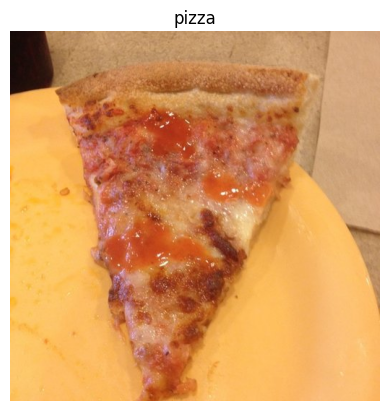

In [7]:
# View a random image from the training dataset
img = view_random_image(target_dir="pizza_steak/train/",
                        target_class="pizza")

In [9]:
# The images we've imported and plotted are actually giant arrays/tensors of different pixel values
import tensorflow as tf
tf.constant(img)

<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[ 74,  71,  78],
        [ 71,  68,  75],
        [ 65,  64,  70],
        ...,
        [132, 124, 103],
        [137, 129, 106],
        [122, 114,  91]],

       [[ 94,  91,  98],
        [ 92,  89,  96],
        [ 87,  86,  92],
        ...,
        [143, 135, 114],
        [147, 139, 118],
        [137, 129, 108]],

       [[106, 103, 110],
        [101,  98, 105],
        [ 95,  92,  99],
        ...,
        [146, 137, 120],
        [147, 138, 121],
        [138, 130, 111]],

       ...,

       [[239, 240, 208],
        [239, 240, 208],
        [238, 239, 205],
        ...,
        [210, 224, 227],
        [211, 225, 228],
        [212, 226, 229]],

       [[242, 243, 211],
        [242, 243, 211],
        [241, 242, 208],
        ...,
        [212, 226, 229],
        [212, 226, 229],
        [213, 227, 230]],

       [[244, 245, 213],
        [244, 245, 213],
        [243, 244, 210],
        ...,
        [214, 228, 23

In [8]:
# View the image shape
img.shape # return width, height. colour channels

(512, 512, 3)

In [9]:
# Get all the pixel values between 0 and 1
img/255.

array([[[0.08627451, 0.04705882, 0.04313725],
        [0.08627451, 0.04705882, 0.04313725],
        [0.08627451, 0.03921569, 0.03921569],
        ...,
        [0.81568627, 0.62745098, 0.47843137],
        [0.81960784, 0.63137255, 0.48235294],
        [0.82352941, 0.63529412, 0.48627451]],

       [[0.08235294, 0.04313725, 0.03921569],
        [0.07843137, 0.03921569, 0.03529412],
        [0.08235294, 0.03529412, 0.03529412],
        ...,
        [0.81568627, 0.62745098, 0.47843137],
        [0.81568627, 0.62745098, 0.47843137],
        [0.81568627, 0.62745098, 0.47843137]],

       [[0.08235294, 0.04313725, 0.03921569],
        [0.07843137, 0.03921569, 0.03529412],
        [0.07843137, 0.03137255, 0.03137255],
        ...,
        [0.81568627, 0.62745098, 0.47843137],
        [0.81176471, 0.62352941, 0.4745098 ],
        [0.80784314, 0.61960784, 0.47058824]],

       ...,

       [[0.99215686, 0.7372549 , 0.34509804],
        [0.99215686, 0.7372549 , 0.34509804],
        [0.99215686, 0

### An end-to-end example

Let's build a convolutional neural network to find patterns in our images, more specifically we a need way to:

* Load our images
* Preprocess our images
* Build a CNN to find patterns in our images
* Compile our CNN
* Fit the CNN to our training data

In [14]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# set the seed
tf.random.set_seed(42)

# Preprocess data (get all of the pixel values between 0 & 1, also called as Scaling/Normalization)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

# Setup paths to our data directories
train_dir = "pizza_steak/train"
test_dir = "pizza_steak/test"

# Import data from directories and turn it into batches
train_data = train_datagen.flow_from_directory(directory=train_dir,
                                            batch_size=32,
                                            target_size=(224, 224),
                                            class_mode="binary",
                                            seed=42)

valid_data = valid_datagen.flow_from_directory(directory=test_dir,
                                               batch_size=32,
                                               target_size=(224, 224),
                                               class_mode="binary",
                                               seed=42)

# Build a CNN model (same as the Tiny VGG on the CNN explainer website)
model_1 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=10,
                           kernel_size=3,
                           activation="relu",
                           input_shape=(224, 224, 3)),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2,
                              padding="valid"),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compile our CNN
model_1.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Fit the model
history_1 = model_1.fit(train_data, 
                        epochs=5, 
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.



Epoch 1/5


47/47 [==============================] - 26s 526ms/step - loss: 0.6968 - accuracy: 0.5873 - val_loss: 0.6127 - val_accuracy: 0.6740
Epoch 2/5
47/47 [==============================] - 13s 270ms/step - loss: 0.5040 - accuracy: 0.7700 - val_loss: 0.4126 - val_accuracy: 0.8380
Epoch 3/5
47/47 [==============================] - 13s 281ms/step - loss: 0.4283 - accuracy: 0.8087 - val_loss: 0.3801 - val_accuracy: 0.8280
Epoch 4/5
47/47 [==============================] - 15s 326ms/step - loss: 0.3927 - accuracy: 0.8213 - val_loss: 0.3266 - val_accuracy: 0.8680
Epoch 5/5
47/47 [==============================] - 14s 295ms/step - loss: 0.3711 - accuracy: 0.8447 - val_loss: 0.3091 - val_accuracy: 0.8740


In [13]:
len(train_data)

47

In [14]:
model_1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 10)      280       
                                                                 
 conv2d_1 (Conv2D)           (None, 220, 220, 10)      910       
                                                                 
 max_pooling2d (MaxPooling2  (None, 110, 110, 10)      0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (None, 108, 108, 10)      910       
                                                                 
 conv2d_3 (Conv2D)           (None, 106, 106, 10)      910       
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 53, 53, 10)        0         
 g2D)                                                   

## Using the same model as before

Let's replicae the model we've built in a previous section to see if it works with out image data.

In [16]:
# Set random seed
tf.random.set_seed(42)

# 1. Create a model to replicate the Tensorflow playground model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224, 3)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2. Compile the nodel
model_2.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# 3. Fit the model
history_2 = model_2.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Epoch 1/5
47/47 [==============================] - 7s 143ms/step - loss: 0.8619 - accuracy: 0.5060 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 2/5
47/47 [==============================] - 6s 137ms/step - loss: 0.6932 - accuracy: 0.5000 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 3/5
47/47 [==============================] - 6s 129ms/step - loss: 0.6932 - accuracy: 0.5000 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 4/5
47/47 [==============================] - 6s 127ms/step - loss: 0.6932 - accuracy: 0.5000 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 5/5
47/47 [==============================] - 6s 130ms/step - loss: 0.6932 - accuracy: 0.5000 - val_loss: 0.6932 - val_accuracy: 0.5000


In [17]:
# Get a summary of model_2
model_2.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_4 (Flatten)         (None, 150528)            0         
                                                                 
 dense_8 (Dense)             (None, 4)                 602116    
                                                                 
 dense_9 (Dense)             (None, 4)                 20        
                                                                 
 dense_10 (Dense)            (None, 1)                 5         
                                                                 
Total params: 602141 (2.30 MB)
Trainable params: 602141 (2.30 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Despite having 20x more parameters than our CNN (model_1), model_2 performs terribly, let's try to improve it.

In [22]:
# Set the random seed
tf.random.set_seed(42)

# 1. Create the model
model_3 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224, 3)),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2. Compile the model
model_3.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# 3. Fit the model
history_3 = model_3.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Epoch 1/5
47/47 [==============================] - 20s 403ms/step - loss: 3.5592 - accuracy: 0.6367 - val_loss: 0.5766 - val_accuracy: 0.7540
Epoch 2/5
47/47 [==============================] - 17s 370ms/step - loss: 1.1798 - accuracy: 0.6747 - val_loss: 0.6304 - val_accuracy: 0.7920
Epoch 3/5
47/47 [==============================] - 17s 367ms/step - loss: 1.1423 - accuracy: 0.7000 - val_loss: 0.5624 - val_accuracy: 0.7780
Epoch 4/5
47/47 [==============================] - 17s 365ms/step - loss: 0.7890 - accuracy: 0.7227 - val_loss: 0.6944 - val_accuracy: 0.6860
Epoch 5/5
47/47 [==============================] - 17s 361ms/step - loss: 0.5620 - accuracy: 0.7740 - val_loss: 0.4635 - val_accuracy: 0.7740


In [23]:
# model_3 summary
model_3.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_5 (Flatten)         (None, 150528)            0         
                                                                 
 dense_20 (Dense)            (None, 100)               15052900  
                                                                 
 dense_21 (Dense)            (None, 100)               10100     
                                                                 
 dense_22 (Dense)            (None, 100)               10100     
                                                                 
 dense_23 (Dense)            (None, 1)                 101       
                                                                 
Total params: 15073201 (57.50 MB)
Trainable params: 15073201 (57.50 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## Binary Classification:

1. Become one with the data (visualize, visualize, visualize)
2. Preprocess the data (prepared it for our  model, the main step here was scaling/normalizing)
3. Created a model (start with a baseline)
4. Fit the model
5. Evaluate the model
6. Adjust different parameters and improve the model (try to beat our baseline)
7. Repeat until satisfied (experiment, experiment, experiment)

### 1. Become one with the data

['3110387.jpg']
Image shape: (512, 512, 3)
['812349.jpg']
Image shape: (512, 512, 3)


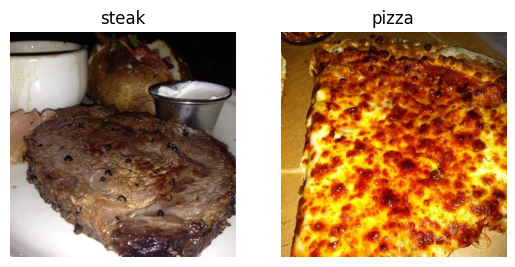

In [29]:
# Visualize data
plt.figure()
plt.subplot(1, 2, 1)
steak_img = view_random_image("pizza_steak/train/", "steak")
plt.subplot(1, 2, 2)
pizza_img = view_random_image("pizza_steak/train/", "pizza")

### 2. Preprocess the data (prepare it for a model)

In [30]:
# Define directory dataset paths
train_dir = "pizza_steak/train/"
test_dir = "pizza_steak/test/"

Our next step is to turn our data into **batches**

A batch is a small subset of data. Rather than look at all 10000 images at one time , a model might only look at 32 at a time.
It does this for a couple of reasons:
1. 10000 images (or more) might not fit into the memory of your processor (GPU).
2. Trying to learn the patterns in 10000 images in one hit could result in the model not being able to learn very well

In [31]:
!nvidia-smi

Thu Feb 22 18:49:26 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 546.33                 Driver Version: 546.33       CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                     TCC/WDDM  | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce GTX 1650      WDDM  | 00000000:01:00.0  On |                  N/A |
| N/A   46C    P5               6W /  50W |    123MiB /  4096MiB |     24%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [33]:
# Create train and test data generators and rescale the data
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

In [34]:
# Load in our image data from directories and turn them into batches
train_data = train_datagen.flow_from_directory(directory=train_dir,
                                               target_size=(224, 224),
                                               class_mode="binary",
                                               batch_size=32)

test_data = test_datagen.flow_from_directory(directory=test_dir,
                                             target_size=(224, 224),
                                             class_mode="binary",
                                             batch_size=32)

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [35]:
# Get a sample of a train data batch
images, labels = train_data.next() 
len(images), len(labels)

(32, 32)

In [36]:
# no of batches
len(train_data)

47

In [37]:
# Get the first two images
images[:2], images[0].shape

(array([[[[0.47058827, 0.40784317, 0.34509805],
          [0.48627454, 0.42352945, 0.36078432],
          [0.48627454, 0.43529415, 0.37254903],
          ...,
          [0.82745105, 0.7137255 , 0.48627454],
          [0.8431373 , 0.7372549 , 0.5294118 ],
          [0.87843144, 0.77647066, 0.58431375]],
 
         [[0.50980395, 0.427451  , 0.36078432],
          [0.5058824 , 0.42352945, 0.35686275],
          [0.5137255 , 0.4431373 , 0.3647059 ],
          ...,
          [0.82745105, 0.7058824 , 0.48235297],
          [0.82745105, 0.70980394, 0.49803925],
          [0.8431373 , 0.73333335, 0.5372549 ]],
 
         [[0.5254902 , 0.427451  , 0.34901962],
          [0.5372549 , 0.43921572, 0.36078432],
          [0.5372549 , 0.45098042, 0.36078432],
          ...,
          [0.82745105, 0.7019608 , 0.4784314 ],
          [0.82745105, 0.7058824 , 0.4901961 ],
          [0.8352942 , 0.7176471 , 0.5137255 ]],
 
         ...,
 
         [[0.77647066, 0.5647059 , 0.2901961 ],
          [0.77647

In [38]:
# View the first batch of labels
labels

array([1., 1., 0., 1., 0., 0., 0., 1., 0., 1., 0., 0., 1., 0., 0., 0., 1.,
       1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0., 0., 1., 0., 1.],
      dtype=float32)

### 3. Create a CNN model (start with a baseline)

In [40]:
# Make the creating of our model a little easier
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Activation
from tensorflow.keras import Sequential

In [41]:
# 1.  Create the model (this will be our baseline, a layer convolutional neural network)
model_4 = Sequential([
    Conv2D(filters=10, # Filter is the number of sliding windows going across an input (higher = more complex model)
           kernel_size=3, # the size of the sliding window going across an input 
           strides=1, # the size of the step the sliding window takes across an input 
           padding="valid", # if "same", output 
           activation="relu",
           input_shape=(224, 224, 3)),
    Conv2D(10, 3, activation="relu"),
    Conv2D(10, 3, activation="relu"),
    Flatten(),
    Dense(1, activation="sigmoid") # Output layer (working with binary classification so only 1 output neuron)
])

In [46]:
# 2. Compile the model
model_4.compile(loss="binary_crossentropy",
                optimizer=Adam(),
                metrics=["accuracy"])

In [47]:
# Get a summary of our model
model_4.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 222, 222, 10)      280       
                                                                 
 conv2d_5 (Conv2D)           (None, 220, 220, 10)      910       
                                                                 
 conv2d_6 (Conv2D)           (None, 218, 218, 10)      910       
                                                                 
 flatten_6 (Flatten)         (None, 475240)            0         
                                                                 
 dense_24 (Dense)            (None, 1)                 475241    
                                                                 
Total params: 477341 (1.82 MB)
Trainable params: 477341 (1.82 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### 4. Fit the model

In [48]:
# Check the lengths of training and test data generators
len(train_data), len(test_data)

(47, 16)

In [49]:
# 3. Fit the model 
history_4 = model_4.fit(train_data, # Combination of labels and sample data
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
47/47 [==============================] - 30s 601ms/step - loss: 0.6161 - accuracy: 0.6833 - val_loss: 0.3675 - val_accuracy: 0.8380
Epoch 2/5
47/47 [==============================] - 16s 349ms/step - loss: 0.3394 - accuracy: 0.8640 - val_loss: 0.3228 - val_accuracy: 0.8720
Epoch 3/5
47/47 [==============================] - 16s 348ms/step - loss: 0.2033 - accuracy: 0.9373 - val_loss: 0.3418 - val_accuracy: 0.8640
Epoch 4/5
47/47 [==============================] - 16s 342ms/step - loss: 0.0838 - accuracy: 0.9793 - val_loss: 0.3939 - val_accuracy: 0.8480
Epoch 5/5
47/47 [==============================] - 16s 342ms/step - loss: 0.0267 - accuracy: 0.9967 - val_loss: 0.4273 - val_accuracy: 0.8480


### 5. Evaluating our model

<Axes: >

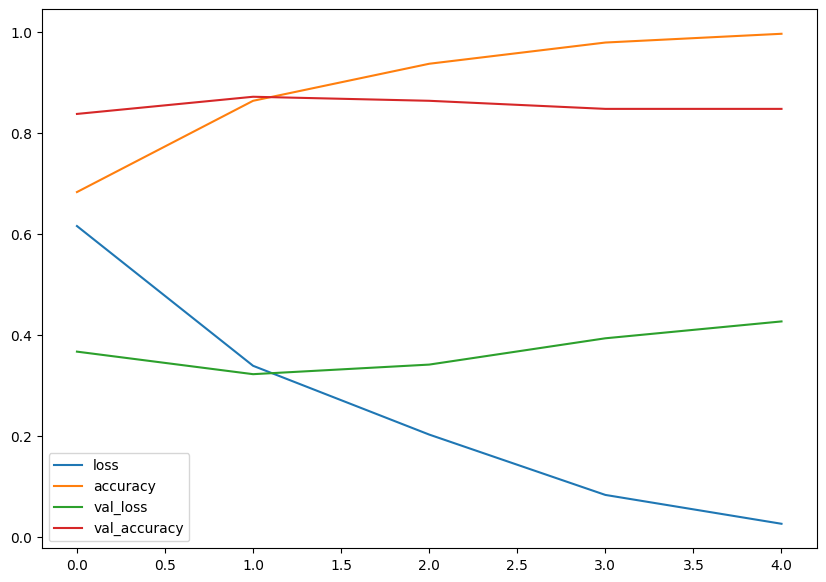

In [50]:
import pandas as pd
pd.DataFrame(history_4.history).plot(figsize=(10, 7))

In [53]:
# Plot the validaiton and training curves separately 
def plot_loss_curves(history):
    """
    Returns separate loss curves for training and validation metrics.
    """
    
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    
    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]
    
    epochs= range(len(history.history["loss"]))
    
    # Plot loss
    plt.plot(epochs, loss, label="training_loss")
    plt.plot(epochs, val_loss, label="val_loss")
    plt.title("loss")
    plt.xlabel("epochs")
    plt.legend()
    
    # Plot accuracy 
    plt.figure()
    plt.plot(epochs, accuracy, label="training_accuracy")
    plt.plot(epochs, val_accuracy, label="val_accuracy")
    plt.title("accuracy")
    plt.xlabel("epochs")
    plt.legend()

**Note:** When a model's **validation loss starts to increase**, it's likely that the model is **overfitting** the training dataset. This means , it's learning the patterns in the training dataset *too well* and thus the model's ability to generalize to unseen data will be diminished.

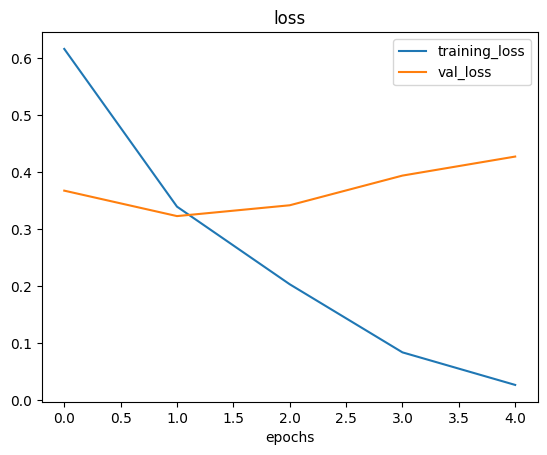

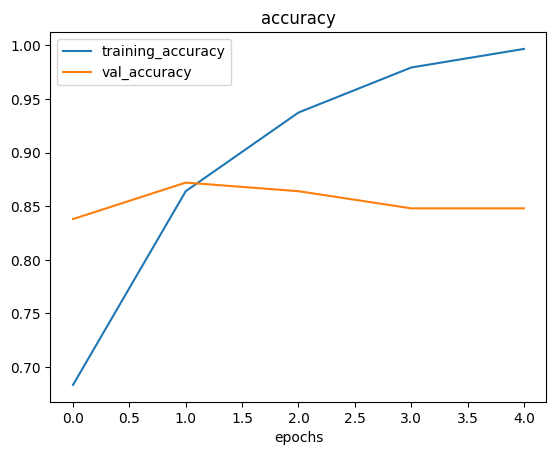

In [54]:
# Check out the loss and accuracy of model_4
plot_loss_curves(history_4)